In [ ]:
import asyncio
asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
data = pd.read_csv('cleaned_life_expectancy_data.csv')


In [9]:
# 1. Сводная информация о данных
print("Размеры датасета:", data.shape)
print("\nОбщая информация:")
data.info()
print("\nПропущенные значения:")
print(data.isnull().sum())


Размеры датасета: (1985, 22)

Общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          1985 non-null   object 
 1   Year                             1985 non-null   int64  
 2   Status                           1985 non-null   object 
 3   Life expectancy                  1985 non-null   float64
 4   Adult Mortality                  1985 non-null   float64
 5   infant deaths                    1985 non-null   int64  
 6   Alcohol                          1985 non-null   float64
 7   percentage expenditure           1985 non-null   float64
 8   Hepatitis B                      1985 non-null   float64
 9   Measles                          1985 non-null   int64  
 10  BMI                              1985 non-null   float64
 11  under-five deaths                1

In [10]:
# 2. Описание числовых столбцов
numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns
print("\nСводная статистика числовых данных:")
print(data[numerical_columns].describe())



Сводная статистика числовых данных:
              Year  Life expectancy   Adult Mortality  infant deaths  \
count  1985.000000       1985.000000      1985.000000    1985.000000   
mean   2007.147103         66.492141       186.680605      40.368262   
std       4.651084          9.226648       129.698101     137.012324   
min    2000.000000         36.300000         1.000000       0.000000   
25%    2003.000000         59.400000        92.000000       1.000000   
50%    2007.000000         68.000000       168.000000       7.000000   
75%    2011.000000         73.600000       262.000000      30.000000   
max    2015.000000         89.000000       723.000000    1800.000000   

           Alcohol  percentage expenditure  Hepatitis B        Measles  \
count  1985.000000             1985.000000  1985.000000    1985.000000   
mean      3.633496               93.036869    81.818136    3124.806045   
std       3.460851              146.231944    23.266636   12992.544358   
min       0.010000

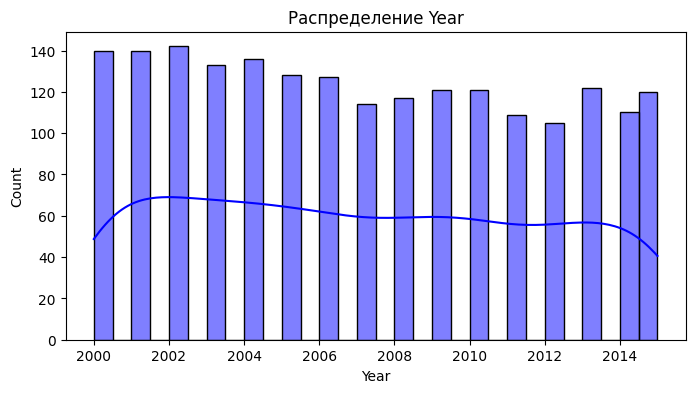

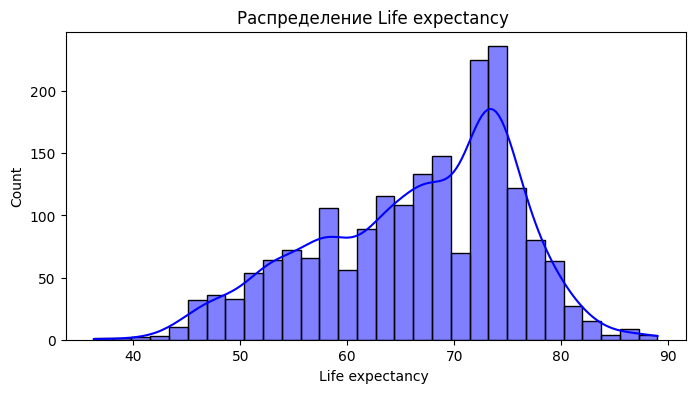

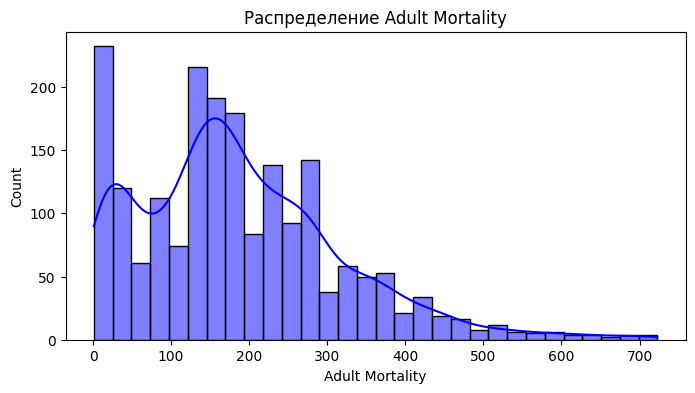

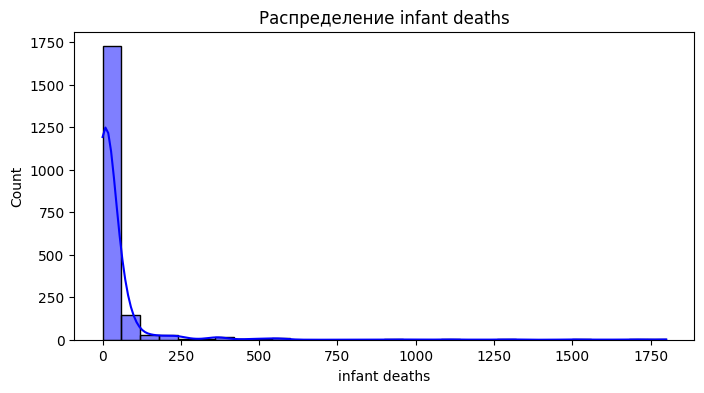

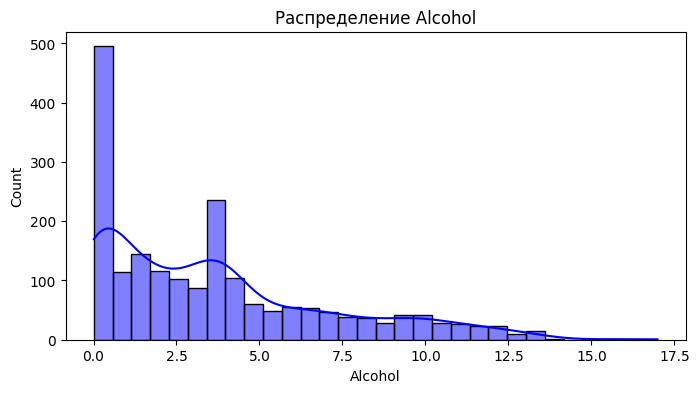

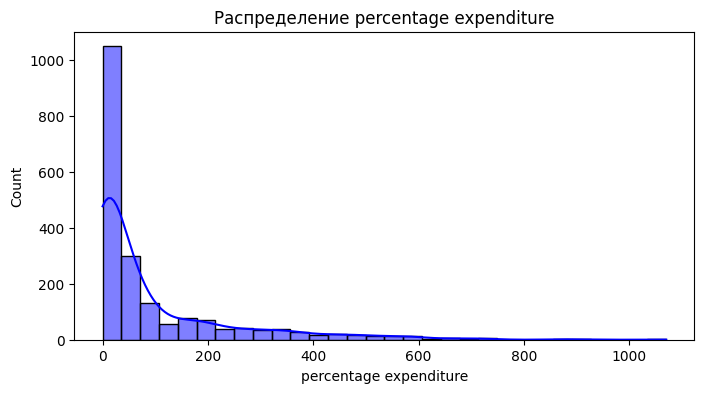

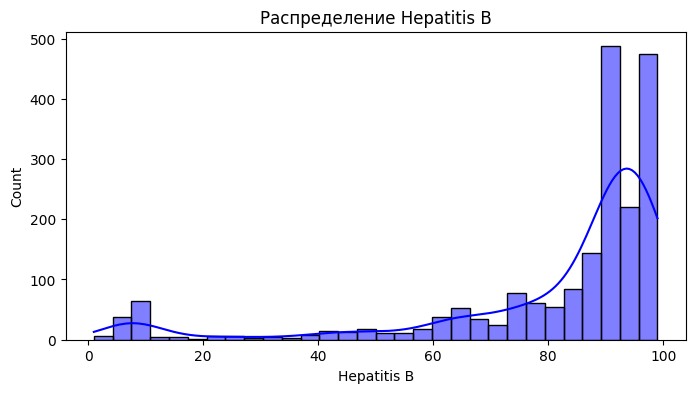

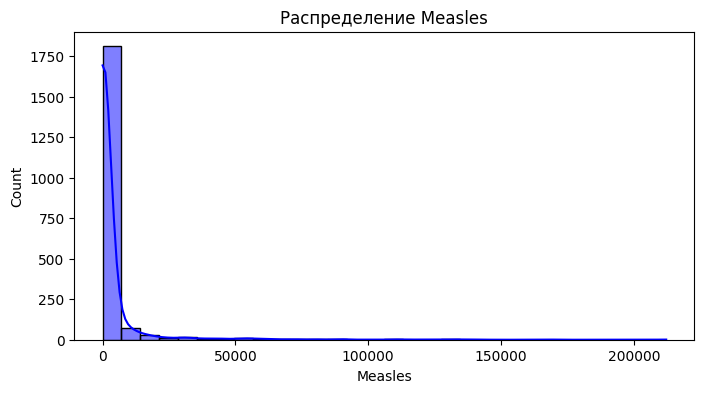

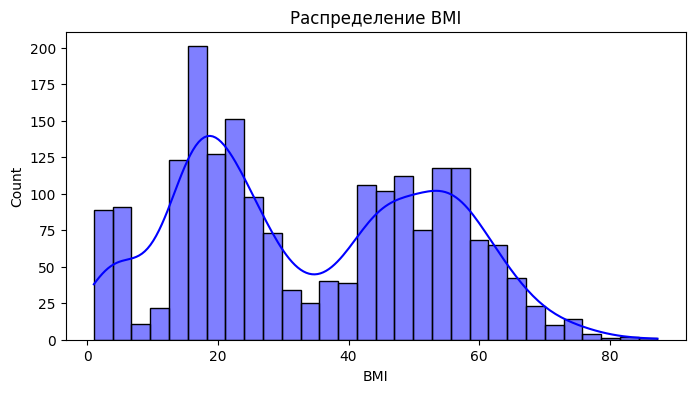

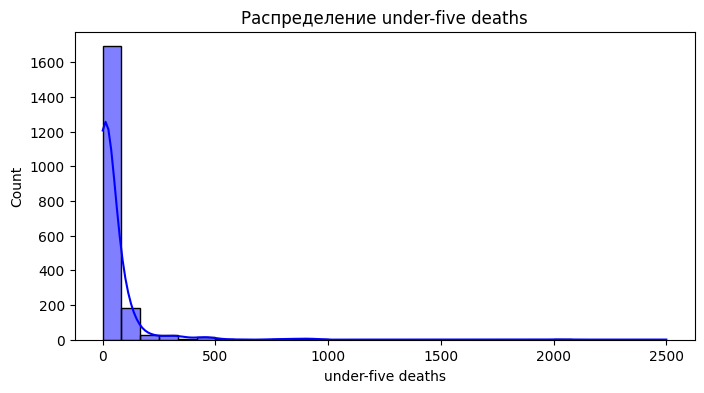

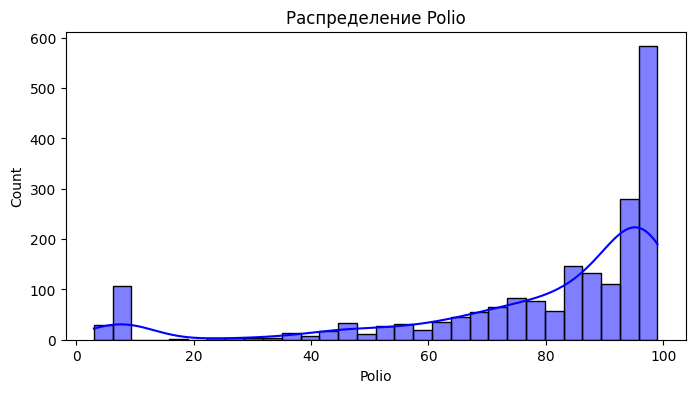

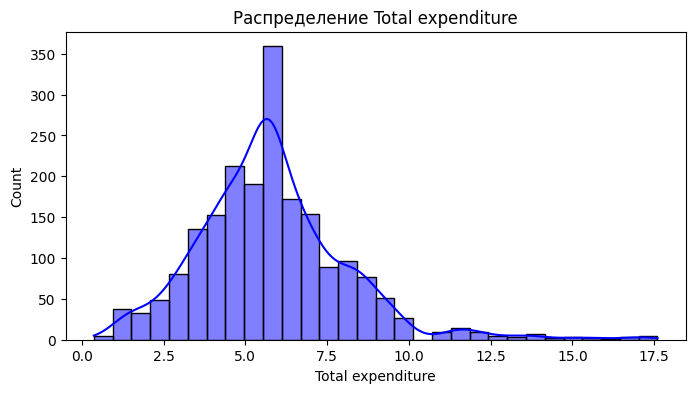

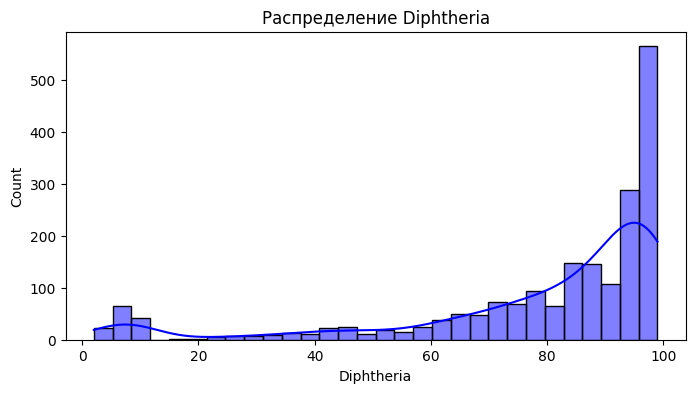

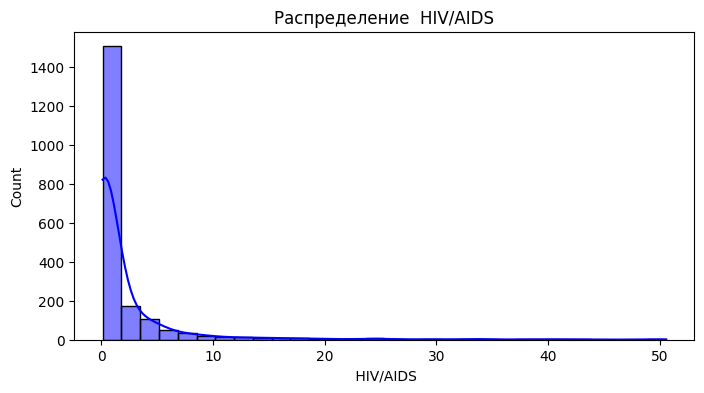

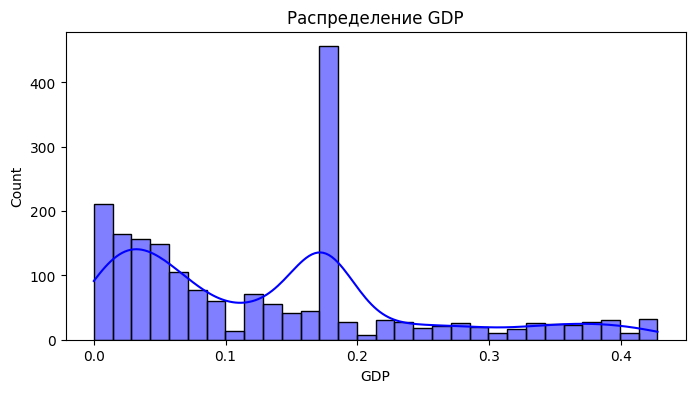

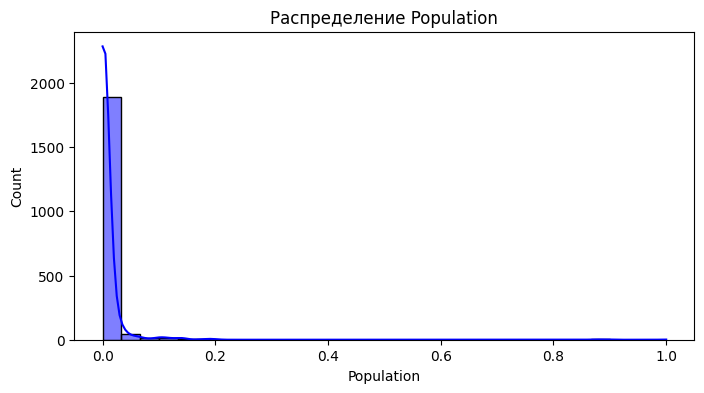

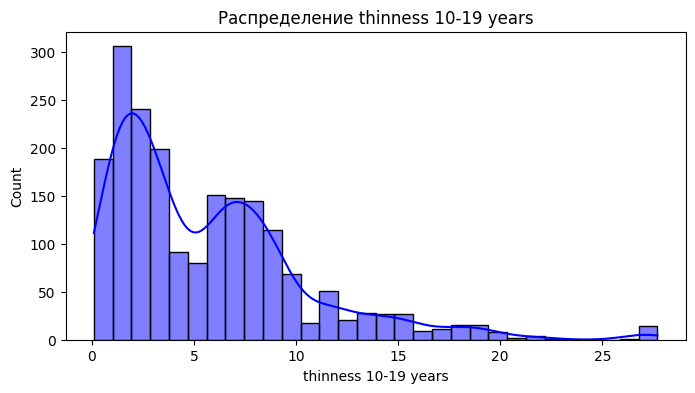

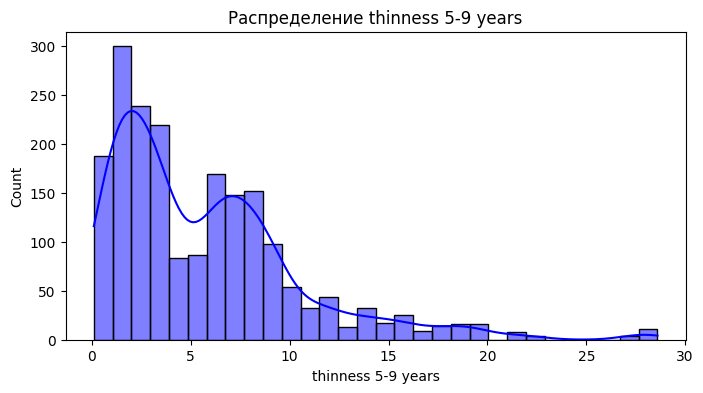

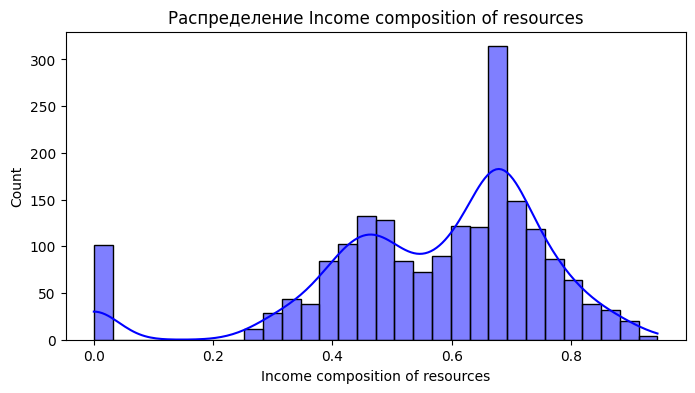

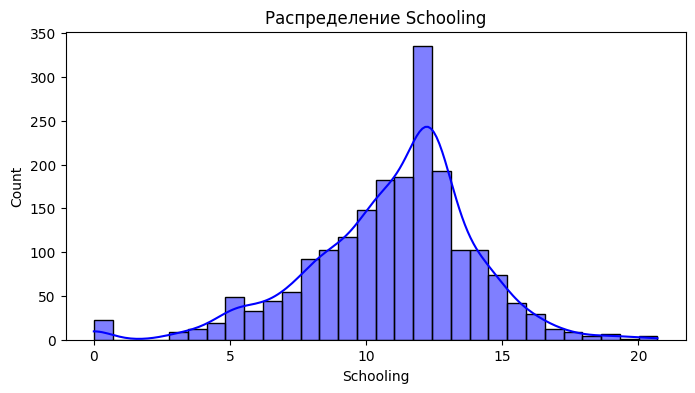

In [11]:
# 3. Гистограммы числовых данных
for col in numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(data[col].dropna(), kde=True, bins=30, color='blue')
    plt.title(f'Распределение {col}')
    plt.show()

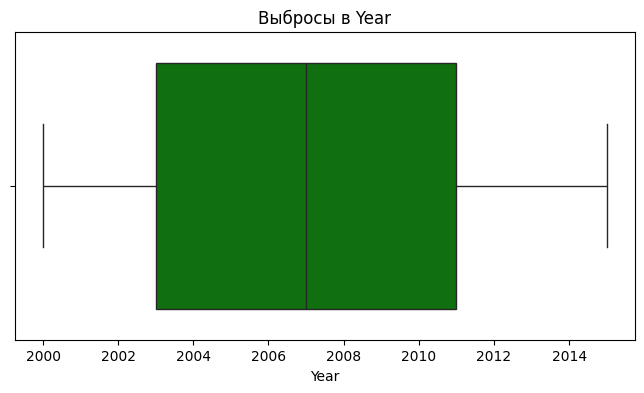

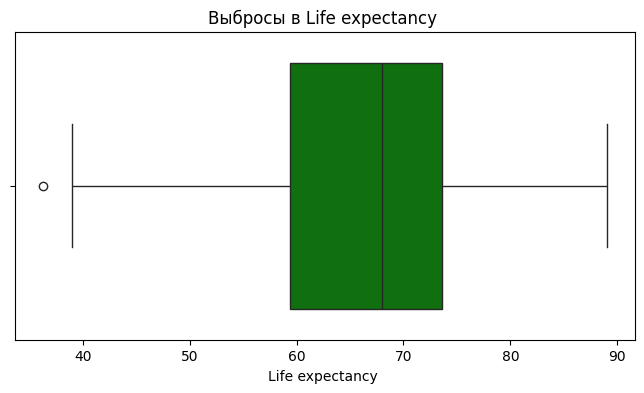

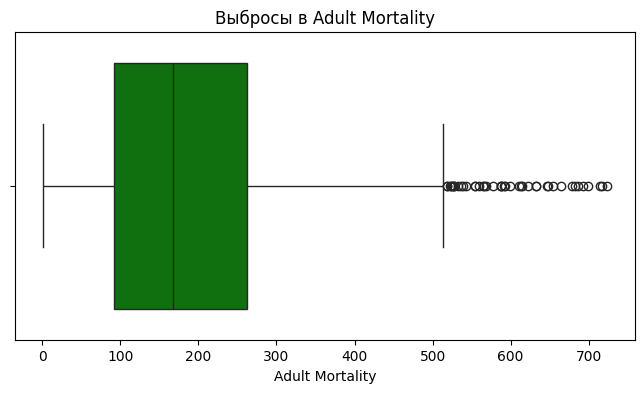

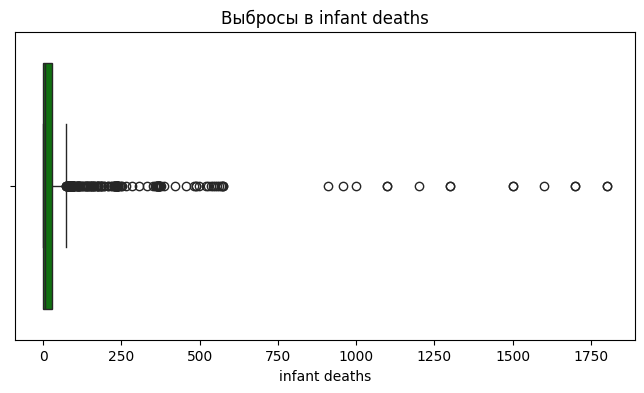

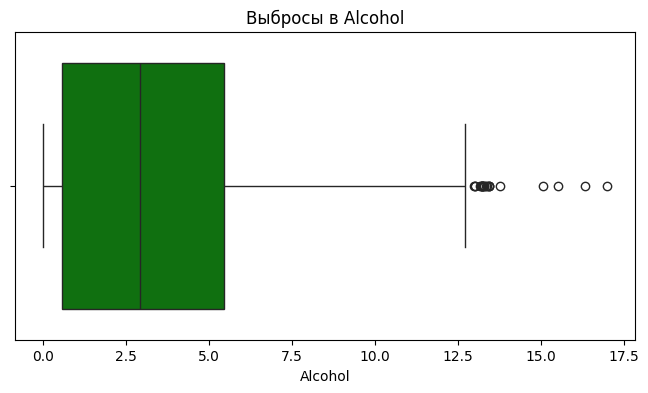

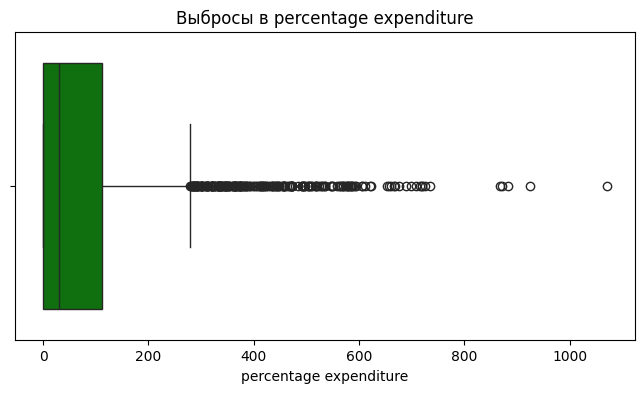

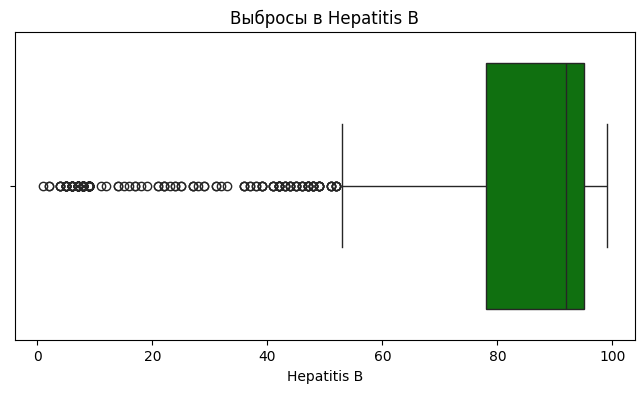

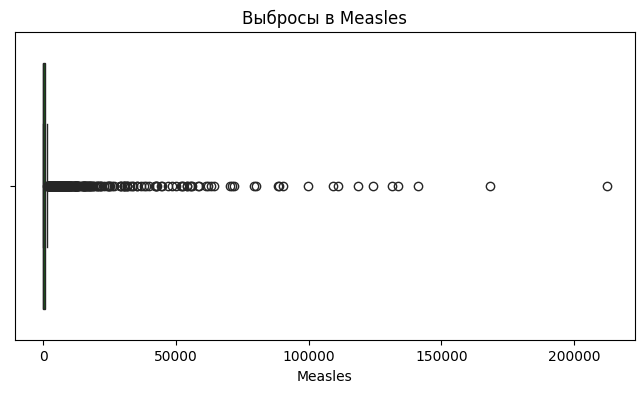

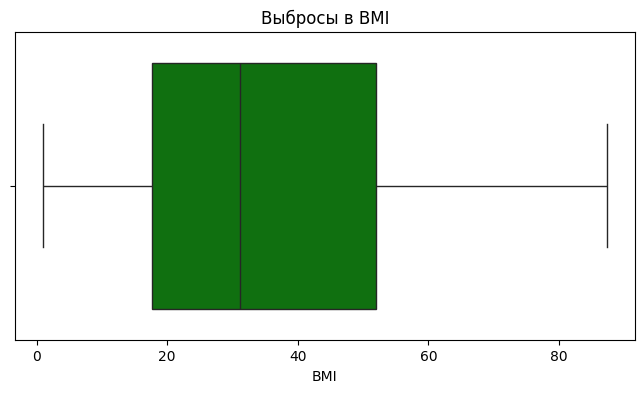

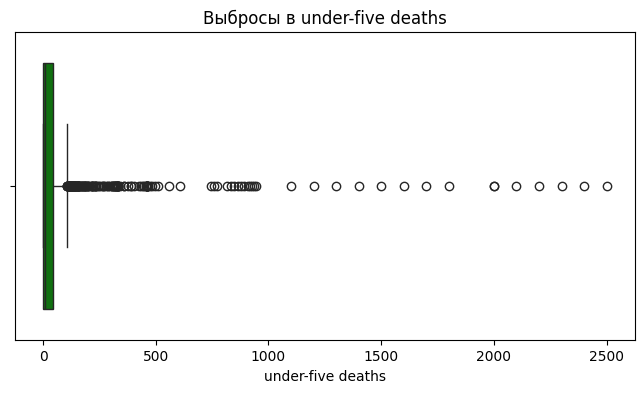

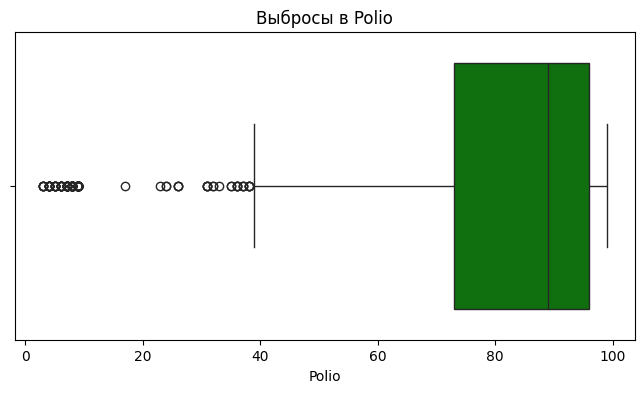

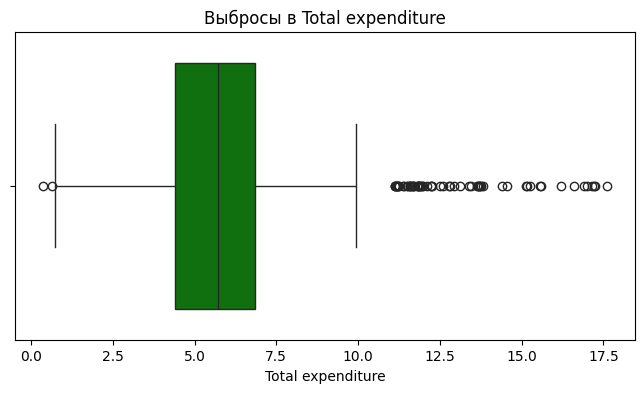

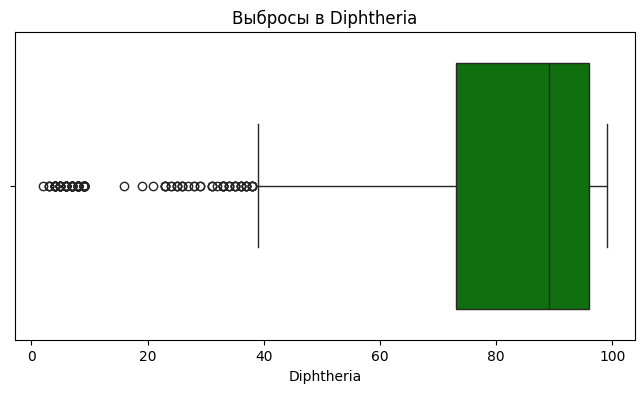

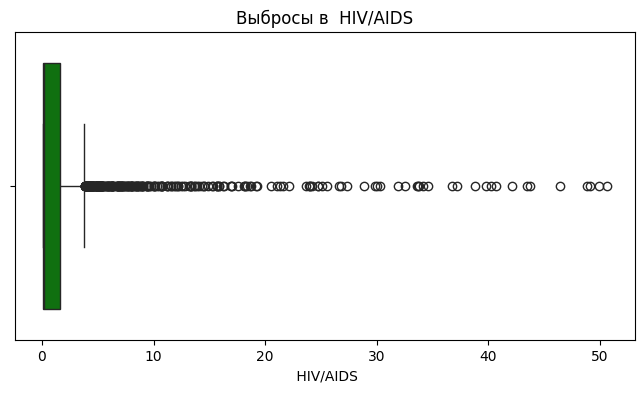

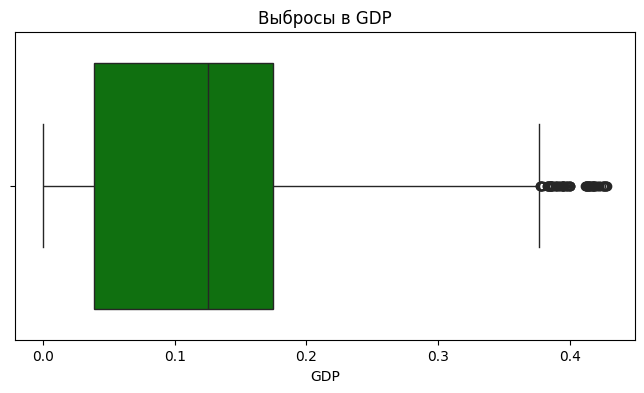

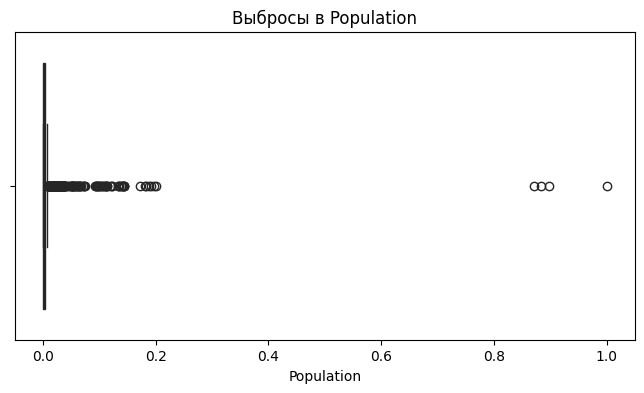

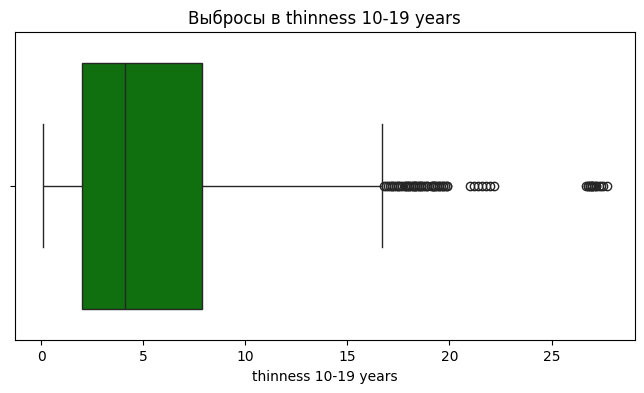

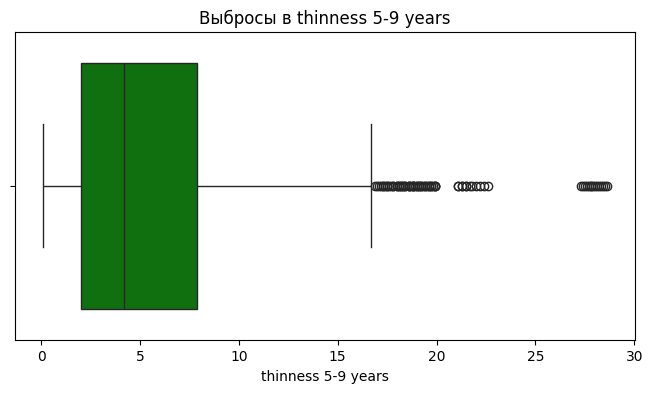

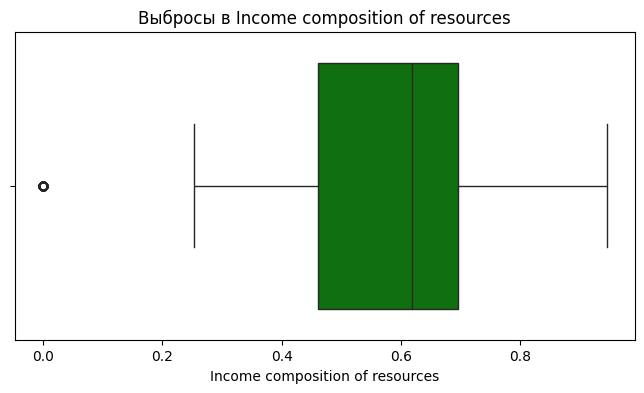

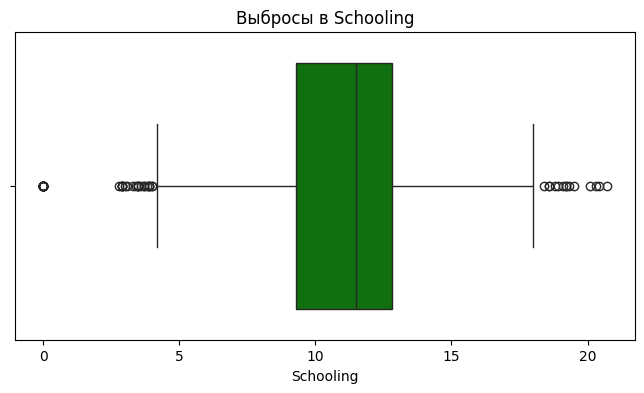

In [12]:
# 4. Коробчатые диаграммы (boxplot) для обнаружения выбросов
for col in numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=data[col].dropna(), color='green')
    plt.title(f'Выбросы в {col}')
    plt.show()

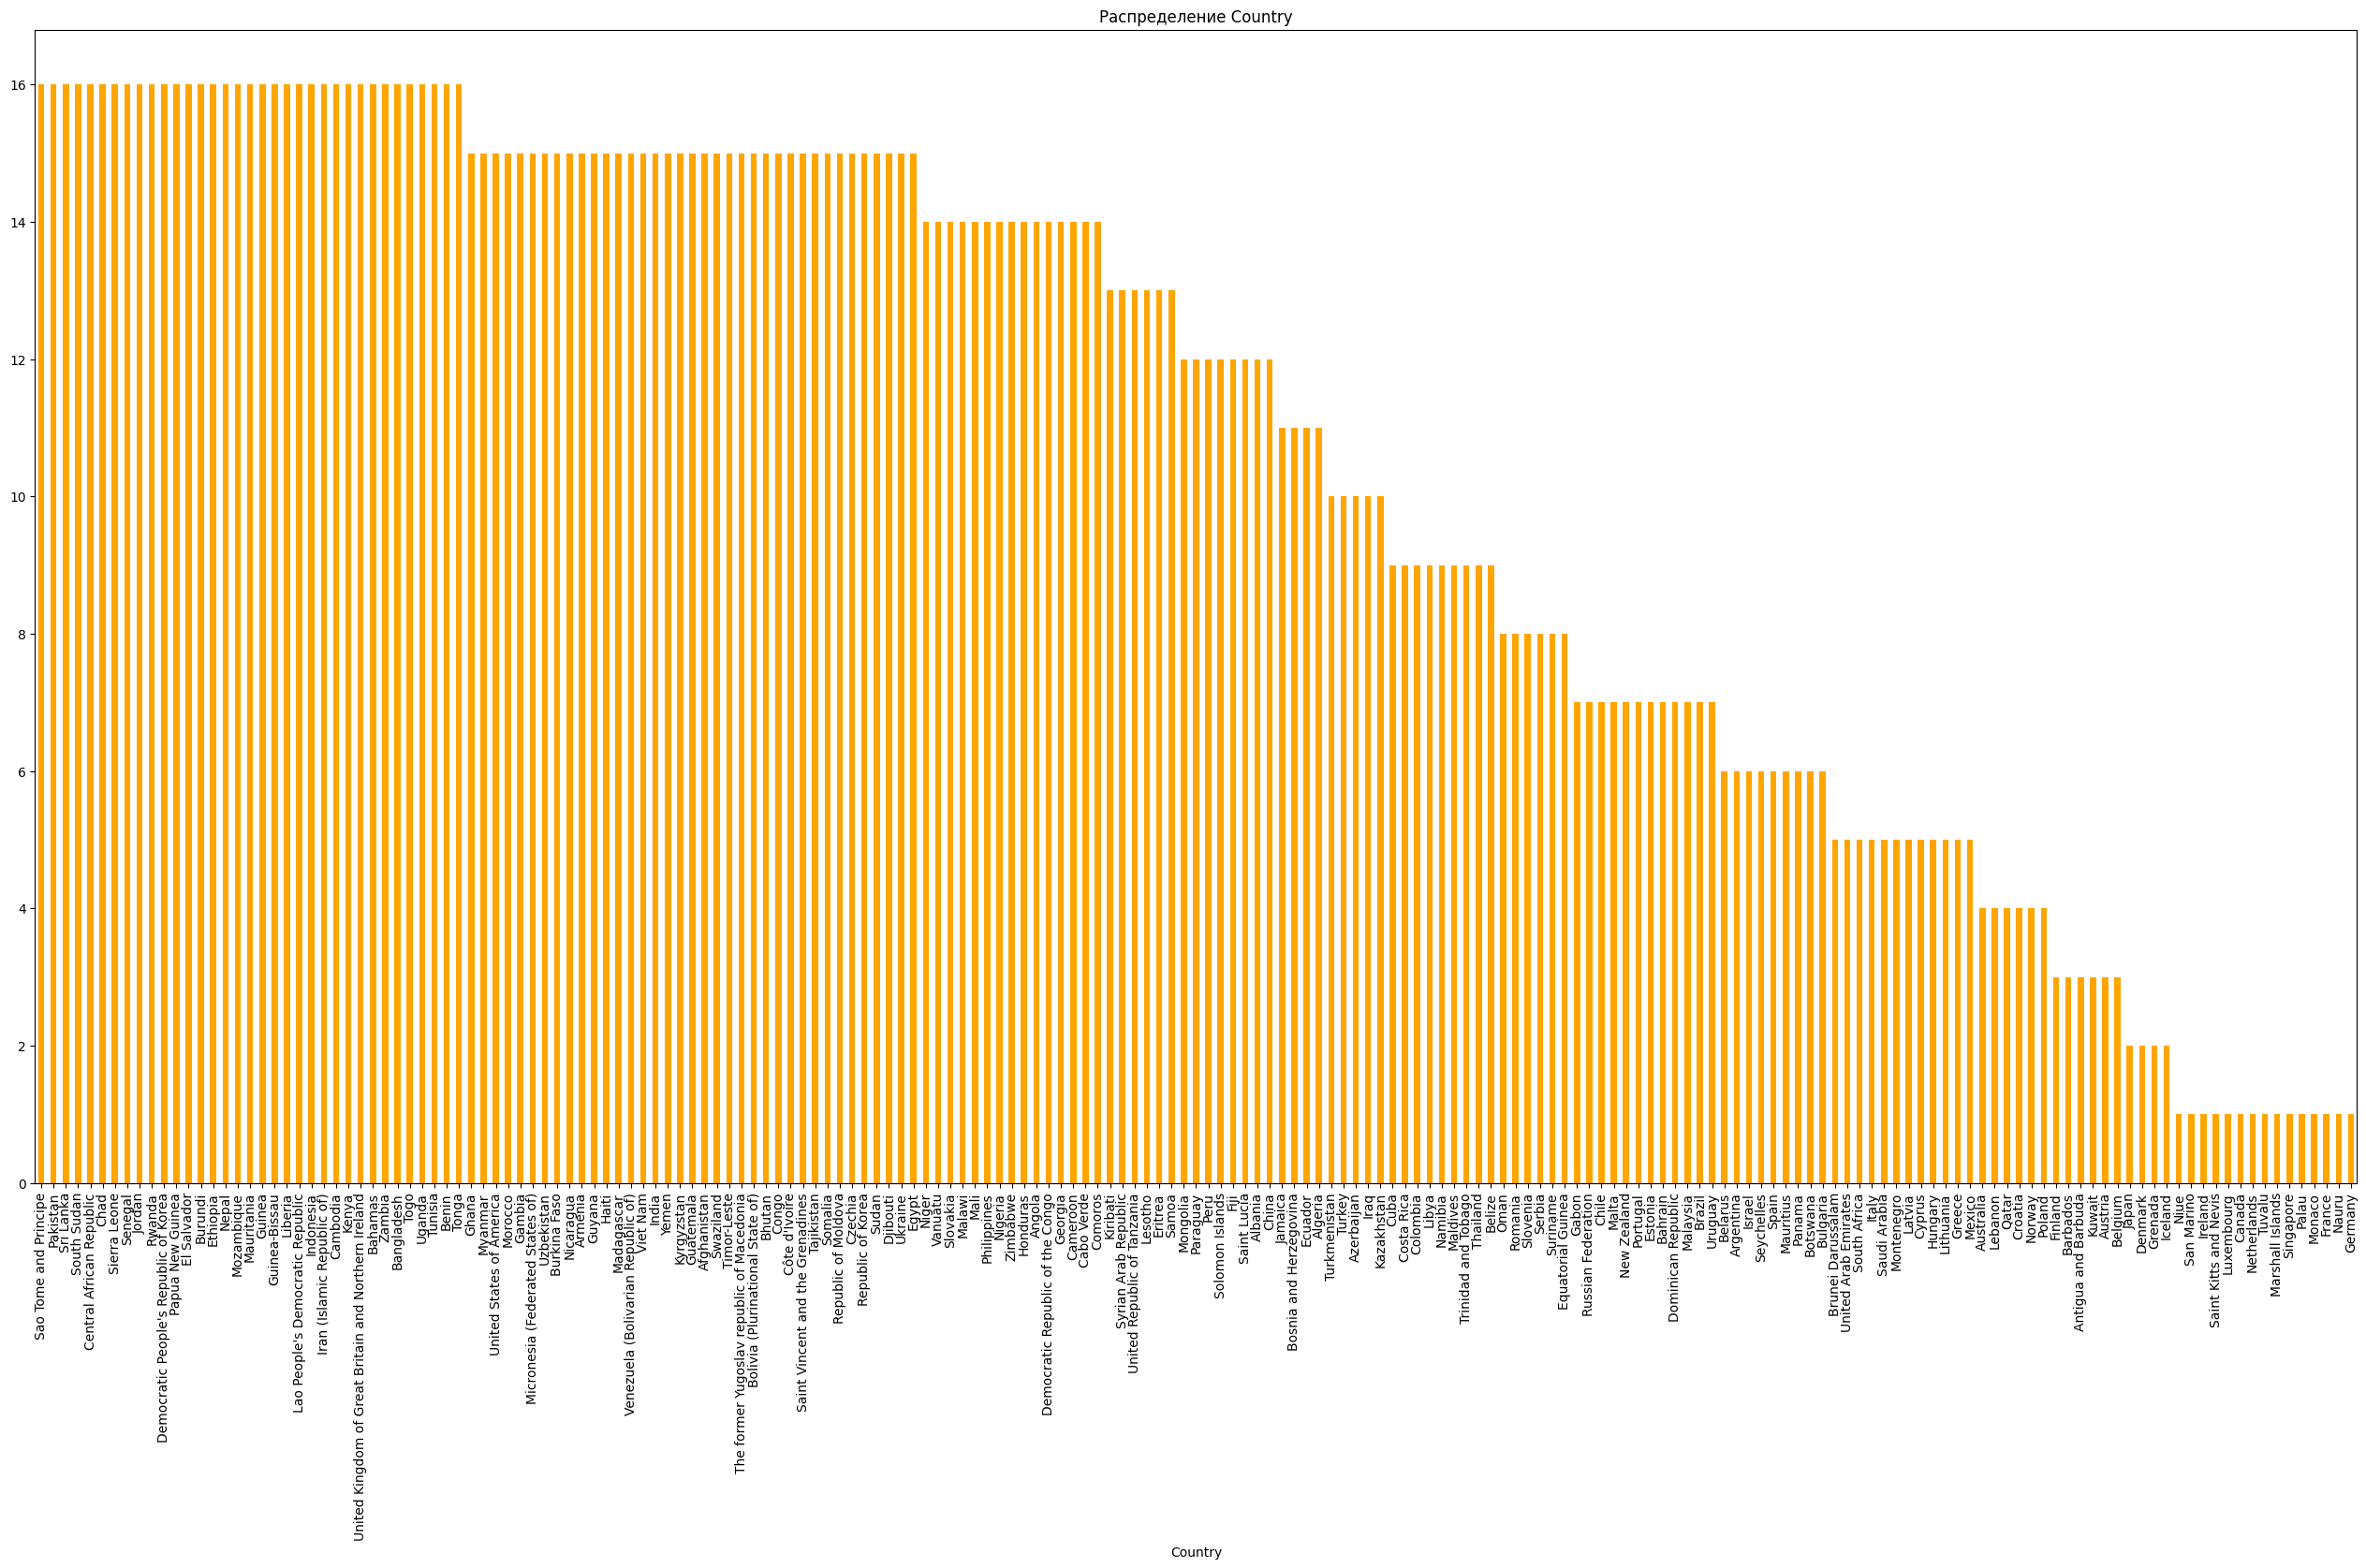

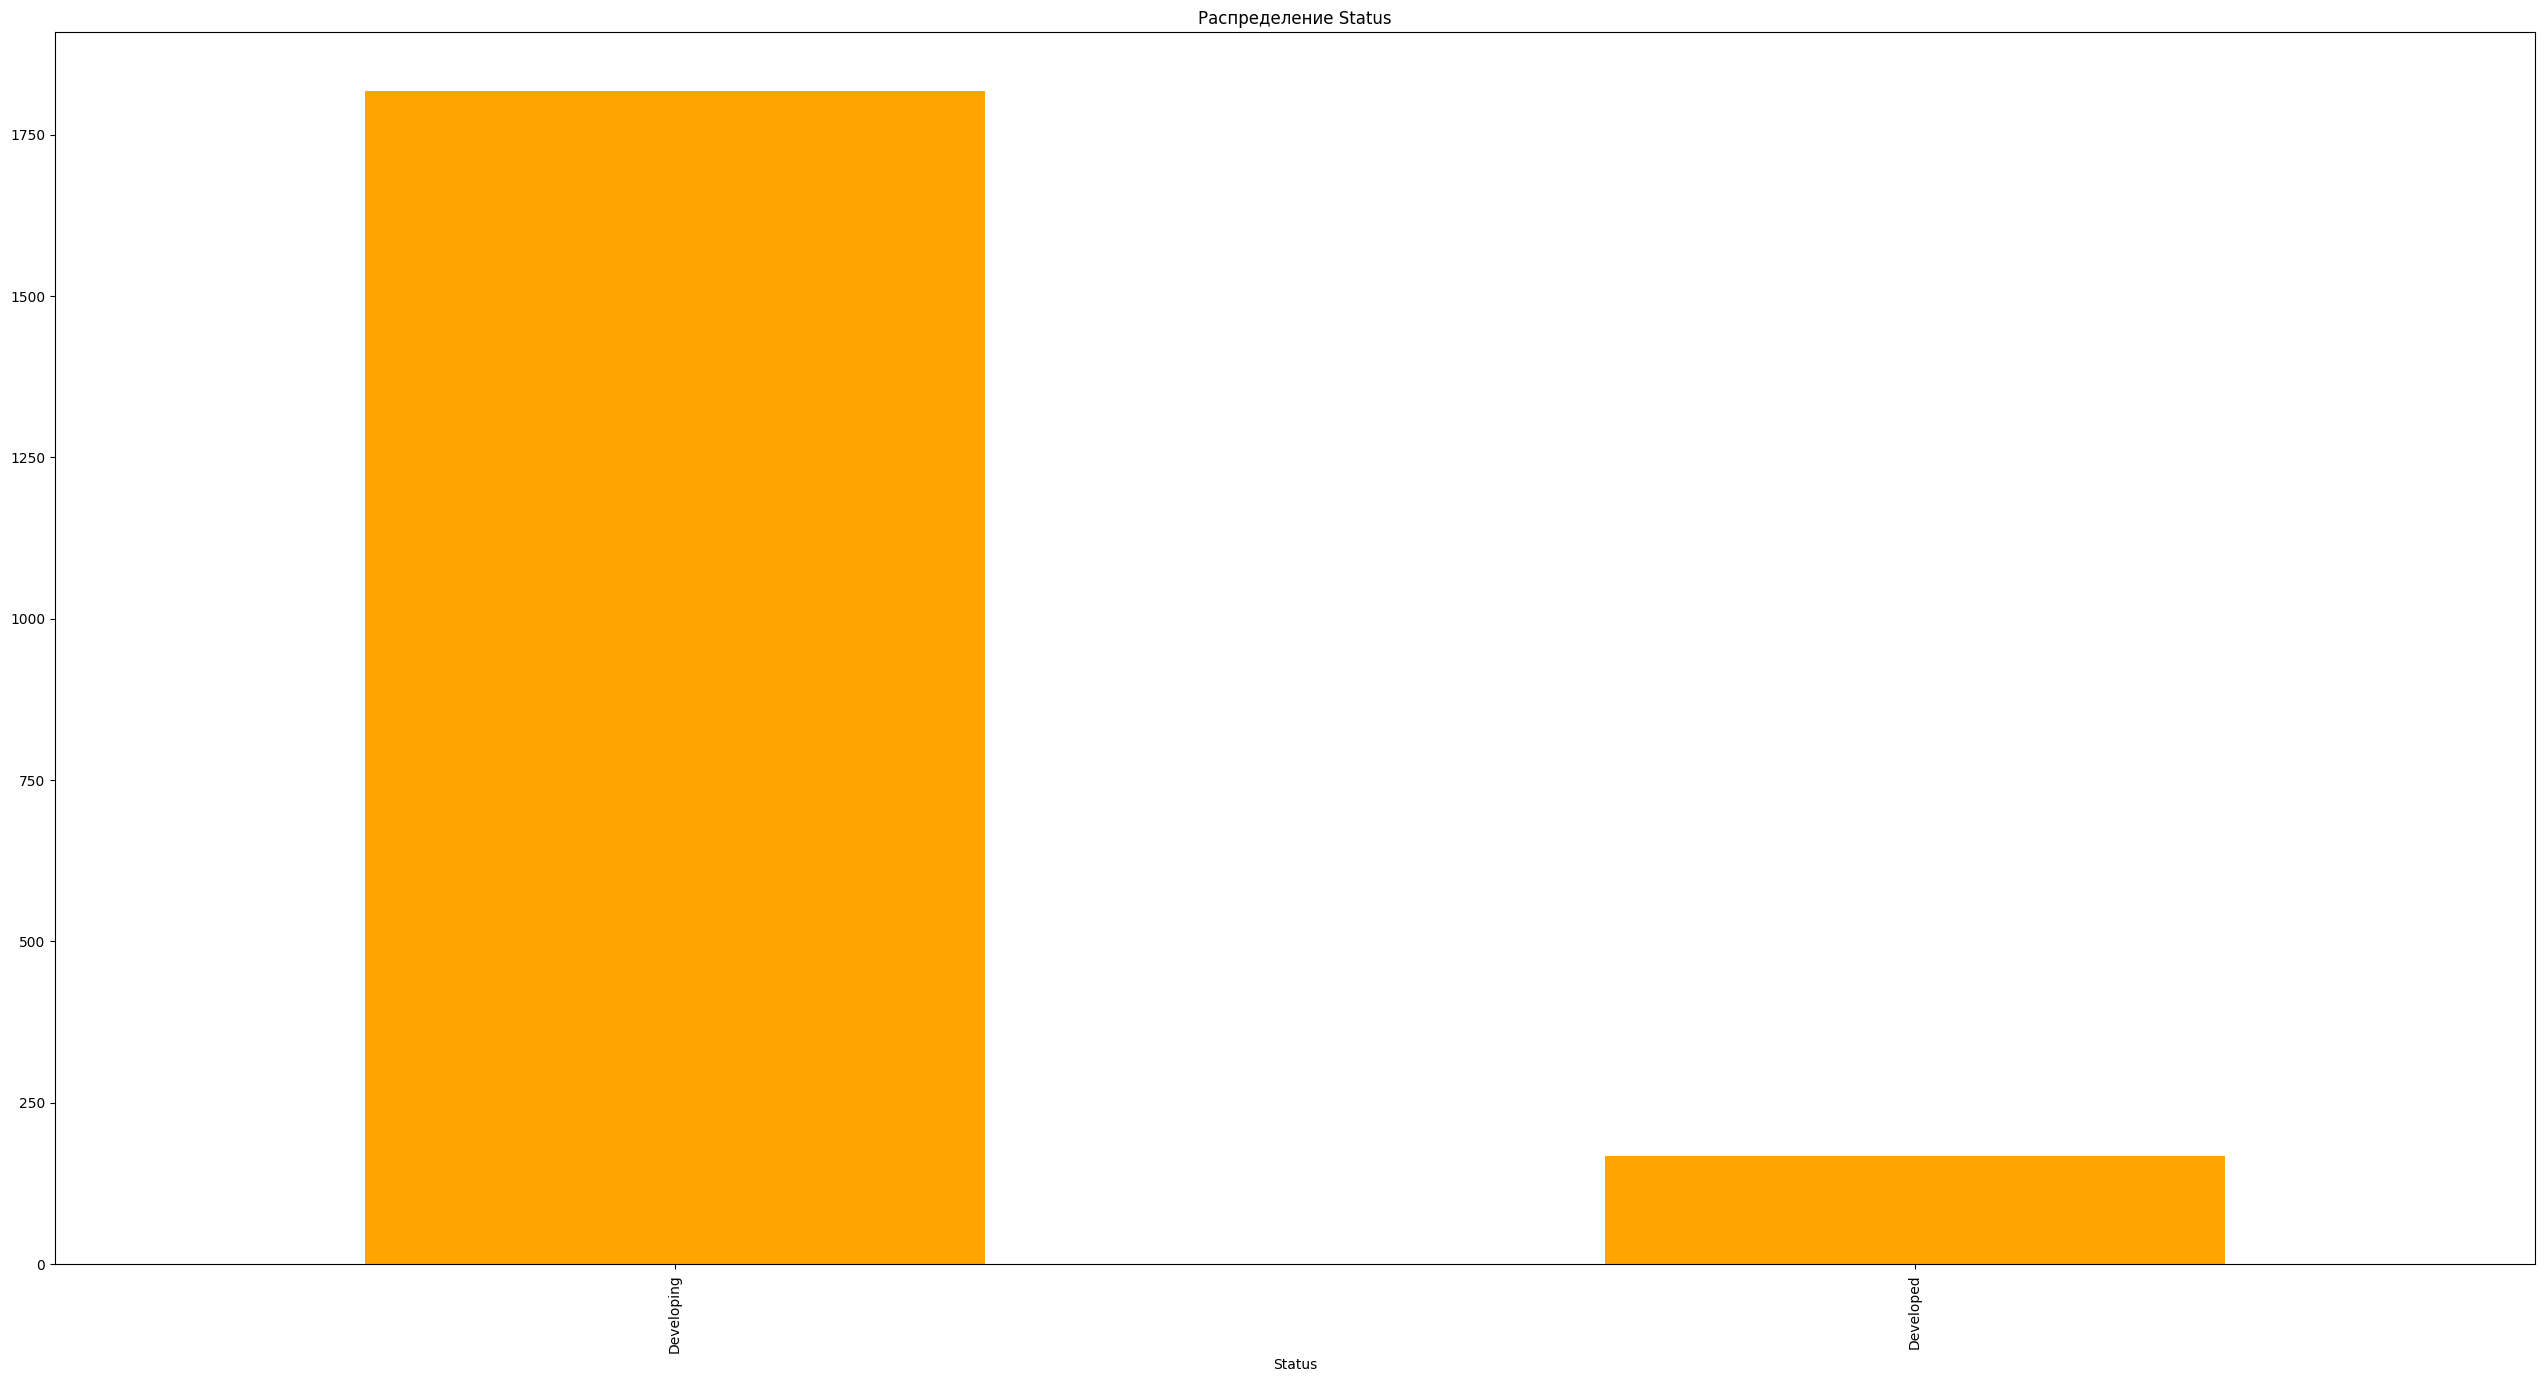

In [13]:
# 5. Анализ категориальных данных
categorical_columns = data.select_dtypes(include=['object']).columns
for col in categorical_columns:
    plt.figure(figsize=(32, 16))
    data[col].value_counts().plot(kind='bar', color='orange')
    plt.title(f'Распределение {col}')
    plt.show()

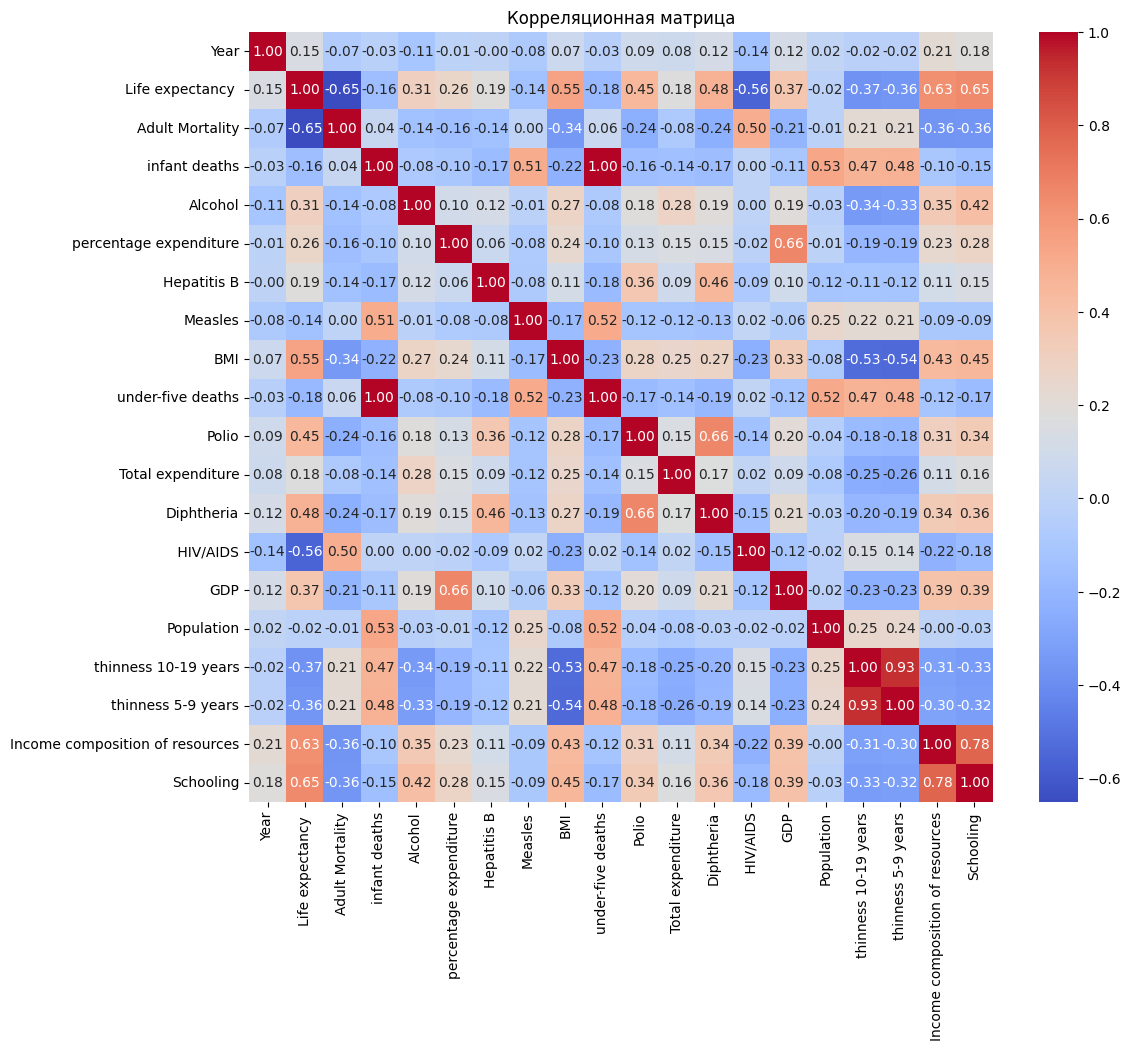

In [14]:
# 6. Корреляционная матрица
plt.figure(figsize=(12, 10))
corr_matrix = data[numerical_columns].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляционная матрица')
plt.show()

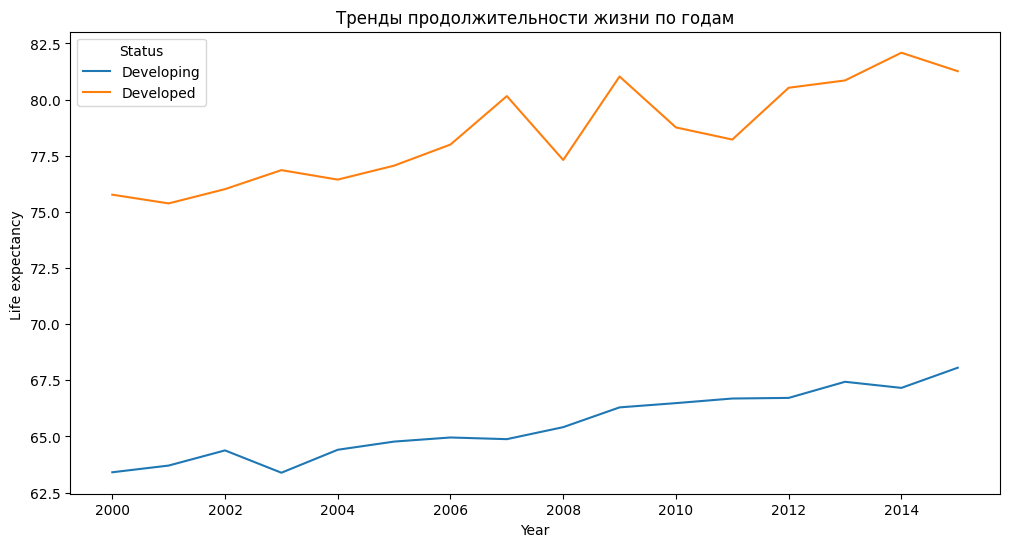

In [15]:
# 7. Временные тренды для продолжительности жизни
if 'Year' in data.columns and 'Life expectancy ' in data.columns:
    plt.figure(figsize=(12, 6))
    sns.lineplot(x='Year', y='Life expectancy ', data=data, hue='Status', errorbar=None)
    plt.title('Тренды продолжительности жизни по годам')
    plt.show()

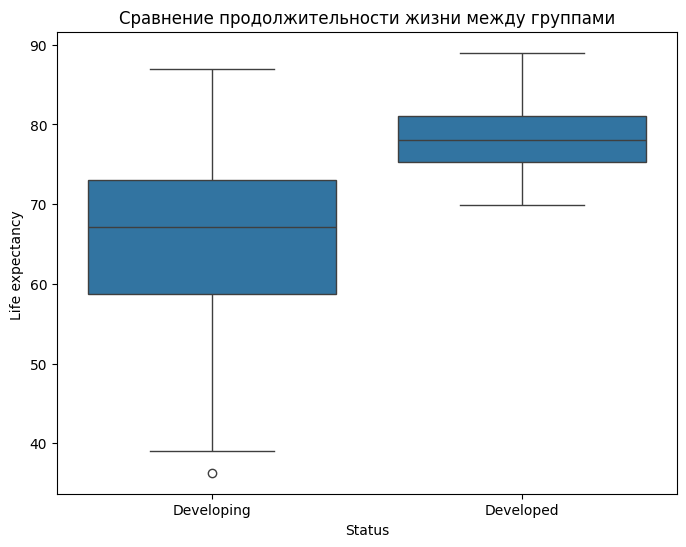

In [16]:
# 8. Сравнение развитых и развивающихся стран
if 'Status' in data.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='Status', y='Life expectancy ', data=data)
    plt.title('Сравнение продолжительности жизни между группами')
    plt.show()

In [17]:
# 9. Выявление аномалий в ключевых столбцах
critical_columns = ['GDP', 'Population']
for col in critical_columns:
    if col in numerical_columns:
        print(f"Аномальные значения в {col}:")
        print(data[data[col] == 0])

Аномальные значения в GDP:
          Country  Year      Status  Life expectancy   Adult Mortality  \
1330  Philippines  2002  Developing              66.8            221.0   

      infant deaths  Alcohol  percentage expenditure  Hepatitis B  Measles  \
1330             68     4.42                0.099872         42.0     7003   

      ...  Polio  Total expenditure  Diphtheria   HIV/AIDS  GDP  Population  \
1330  ...   77.0               2.79        79.0        0.1  0.0    0.000629   

      thinness 10-19 years  thinness 5-9 years  \
1330                   1.0                 9.7   

      Income composition of resources  Schooling  
1330                            0.625       11.4  

[1 rows x 22 columns]
Аномальные значения в Population:
       Country  Year      Status  Life expectancy   Adult Mortality  \
1034  Maldives  2003  Developing              72.7            112.0   

      infant deaths  Alcohol  percentage expenditure  Hepatitis B  Measles  \
1034              0     1.7

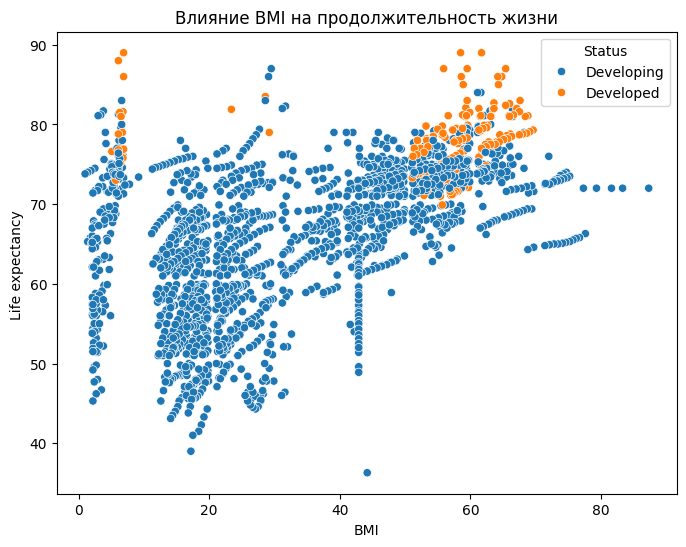

In [18]:
# 10. Анализ распределения BMI и его влияние на продолжительность жизни
if 'BMI' in data.columns and 'Life expectancy ' in data.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='BMI', y='Life expectancy ', data=data, hue='Status')
    plt.title('Влияние BMI на продолжительность жизни')
    plt.show()


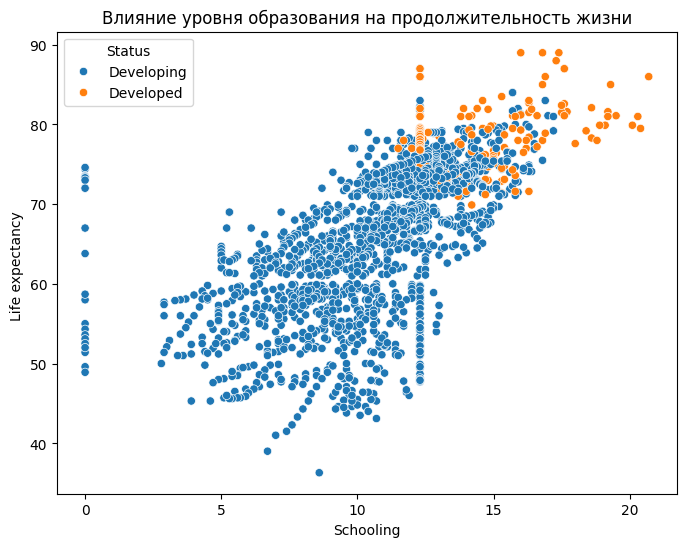

In [19]:
# 11. Анализ уровня образования и продолжительности жизни
if 'Schooling' in data.columns and 'Life expectancy ' in data.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='Schooling', y='Life expectancy ', data=data, hue='Status')
    plt.title('Влияние уровня образования на продолжительность жизни')
    plt.show()


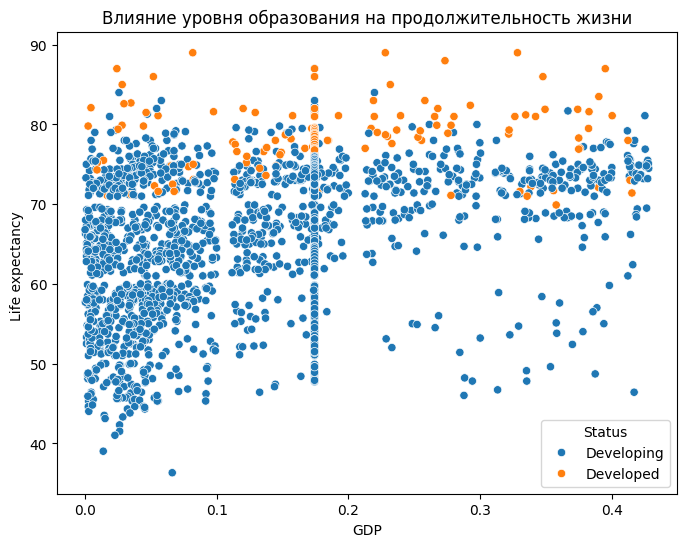

In [20]:
if 'GDP' in data.columns and 'Life expectancy ' in data.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='GDP', y='Life expectancy ', data=data, hue='Status')
    plt.title('Влияние уровня образования на продолжительность жизни')
    plt.show()

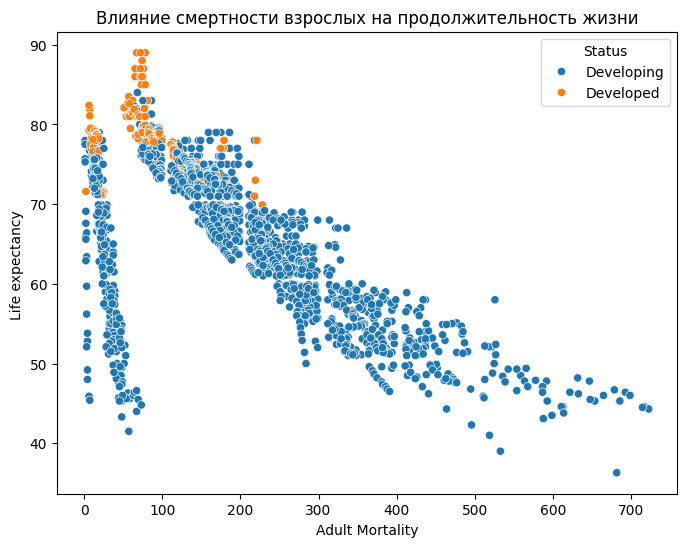

In [21]:
# 13. Исследование смертности и её влияния
if 'Adult Mortality' in data.columns and 'Life expectancy ' in data.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='Adult Mortality', y='Life expectancy ', data=data, hue='Status')
    plt.title('Влияние смертности взрослых на продолжительность жизни')
    plt.show()

In [31]:
# Добавление новых признаков
if 'Income composition of resources' in data.columns and 'Schooling' in data.columns:
    data['Economic_health_index'] = data['Income composition of resources'] * data['Schooling']

if 'Total expenditure' in data.columns and 'GDP' in data.columns:
    data['Health_expenditure_ratio'] = data['Total expenditure'] / data['GDP']

if 'Adult Mortality' in data.columns and 'under-five deaths' in data.columns:
    data['Mortality_rate_ratio'] = data['Adult Mortality'] / data['under-five deaths']

# Просмотр обновлённого датасета
print(data.T.head(25))


                                        0            1            2     \
Country                          Afghanistan  Afghanistan  Afghanistan   
Year                                    2015         2014         2013   
Status                            Developing   Developing   Developing   
Life expectancy                         65.0         59.9         59.9   
Adult Mortality                        263.0        271.0        268.0   
infant deaths                             62           64           66   
Alcohol                                 0.01         0.01         0.01   
percentage expenditure             71.279624    73.523582    73.219243   
Hepatitis B                             65.0         62.0         64.0   
Measles                                 1154          492          430   
BMI                                     19.1         18.6         18.1   
under-five deaths                         83           86           89   
Polio                                 

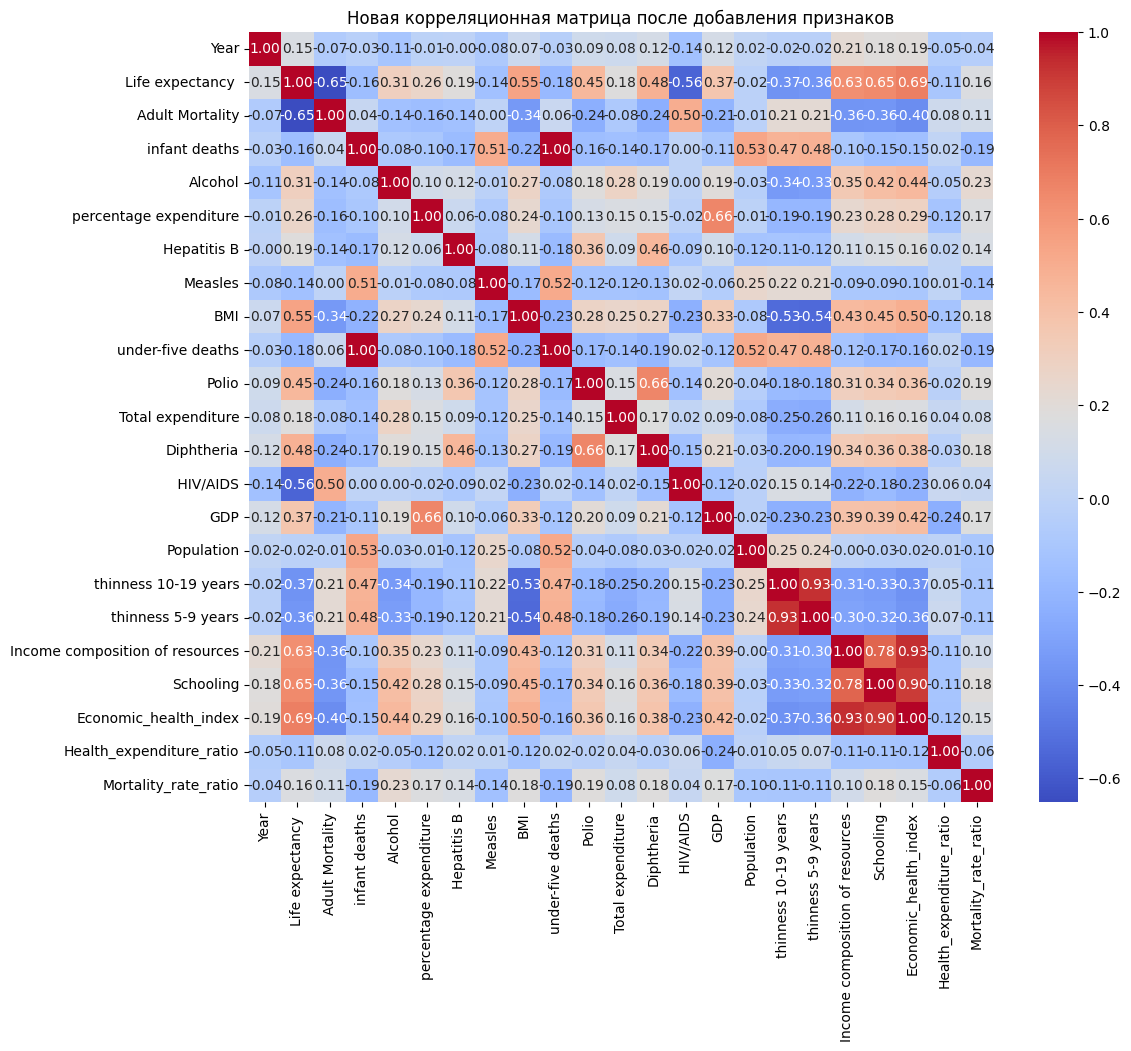

In [27]:
# Построение новой корреляционной матрицы
numerical_columns_cleaned = data.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(12, 10))
corr_matrix_cleaned = data[numerical_columns_cleaned].corr()
sns.heatmap(corr_matrix_cleaned, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Новая корреляционная матрица после добавления признаков')
plt.show()


In [24]:
# 14. Удаление признаков на основе анализа корреляции
features_to_drop = ['Country','Status','Hepatitis B', 'Population', 'under-five deaths', 'Year', 
                    'thinness 5-9 years', 'Measles', 'Total expenditure', 'infant deaths']
data_cleaned = data.drop(columns=features_to_drop, errors='ignore')

print("\nДатасет после удаления признаков:")
print(data_cleaned.head())



Датасет после удаления признаков:
   Life expectancy   Adult Mortality  Alcohol  percentage expenditure   BMI  \
0              65.0            263.0     0.01               71.279624  19.1   
1              59.9            271.0     0.01               73.523582  18.6   
2              59.9            268.0     0.01               73.219243  18.1   
3              59.5            272.0     0.01               78.184215  17.6   
4              59.2            275.0     0.01                7.097109  17.2   

   Polio  Diphtheria   HIV/AIDS       GDP  thinness 10-19 years  \
0    6.0        65.0        0.1  0.058353                  17.2   
1   58.0        62.0        0.1  0.061201                  17.5   
2   62.0        64.0        0.1  0.063109                  17.7   
3   67.0        67.0        0.1  0.066937                  17.9   
4   68.0        68.0        0.1  0.006196                  18.2   

   Income composition of resources  Schooling  Economic_health_index  \
0              

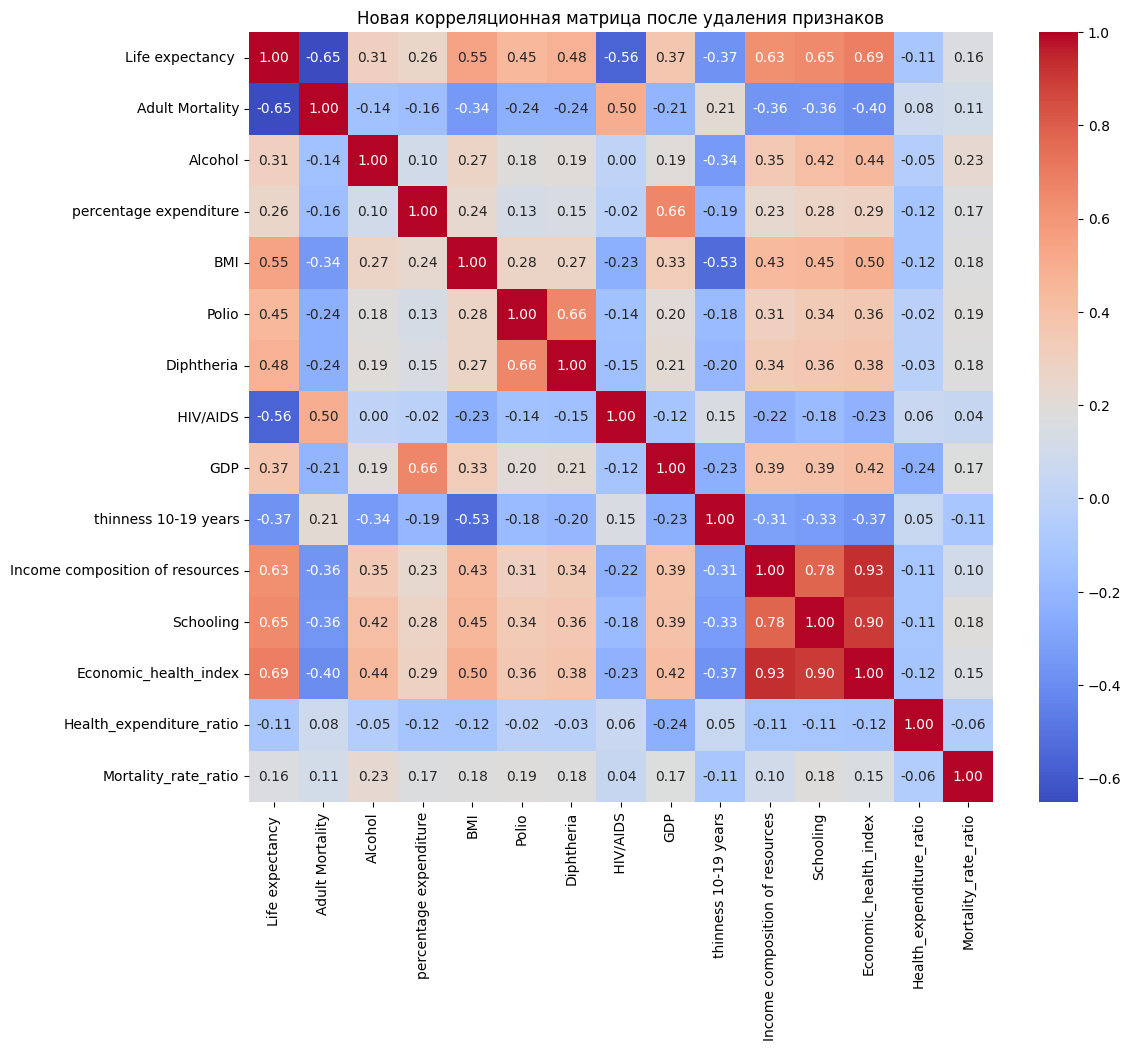

In [25]:
# Построение новой корреляционной матрицы
numerical_columns_cleaned = data_cleaned.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(12, 10))
corr_matrix_cleaned = data_cleaned[numerical_columns_cleaned].corr()
sns.heatmap(corr_matrix_cleaned, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Новая корреляционная матрица после удаления признаков')
plt.show()

In [26]:
data_cleaned = data_cleaned.round(3)
output_file = 'final_dataset.csv'
data_cleaned.to_csv(output_file, index=False)